In [1]:
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install pandas

In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv("/content/Fake_Real_Data.csv")

print(df.shape)

df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Fake_Real_Data.csv'

In [4]:
!ls

Fake.csv  sample_data  True.csv


In [5]:
import pandas as pd

true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

print(true.shape)
print(fake.shape)

true.head()

(21417, 4)
(23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
true['label'] = 1
fake['label'] = 0

In [7]:
df = pd.concat([true, fake])

df = df.sample(frac=1)  # shuffle dataset

df.head()

,title,text,subject,date,label
16654,Pressure on as Xi's 'Belt and Road' enshrined ...,SHANGHAI (Reuters) - Chinese President Xi Jinp...,worldnews,"October 24, 2017",1
770,Republicans Are Trying To Destroy The Senate ...,"The American Legislative Exchange Council, oth...",News,"July 24, 2017",0
10128,THROWING GAS ON RACIAL FIRE? VA Police Confirm...,Will the mainstream media report about this?Co...,politics,"Aug 17, 2017",0
20489,LOL! The Woman Who Couldn’t Be Bothered With P...,"Ironically, the two issues that catapulted Tru...",left-news,"Jun 1, 2016",0
13968,Lebanon's Jumblatt criticizes Saudi over Hariri,BEIRUT (Reuters) - Top Lebanese Druze politici...,worldnews,"November 24, 2017",1


In [8]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 16654 to 21106
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [9]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])
df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
20523,Caribbean islands fear grim tourist season in ...,MEXICO CITY (Reuters) - Hurricane Irma s deadl...,worldnews,"September 8, 2017",1
283,'Good to go': Top Trump aide gave inaugural da...,WASHINGTON (Reuters) - As President Donald Tru...,politicsNews,"December 6, 2017",1
16667,HERE’S WHY AMERICA IS $19 Trillion Dollars In ...,"Detroit and Flint, Michigan are getting yet an...",Government News,"Apr 4, 2016",0
20019,Brazil's Temer faces new graft charges over JB...,BRASILIA (Reuters) - Brazilian President Miche...,worldnews,"September 14, 2017",1
7903,Watch Bernie Sanders Slam The Hell Out Of Rep...,"Bernie s combination of calling it like it is,...",News,"February 24, 2016",0


In [10]:
texts = df['text']
labels = df['label']

In [11]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

NameError: name 'train_test_split' is not defined

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [14]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

NameError: name 'BertTokenizer' is not defined

In [15]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [16]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [18]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

In [19]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    logging_dir='./logs'
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [21]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    logging_dir='./logs'
)

NameError: name 'TrainingArguments' is not defined

In [2]:
from transformers import Trainer, TrainingArguments

In [3]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [4]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [5]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

NameError: name 'model' is not defined

In [6]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [7]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

NameError: name 'model' is not defined

In [8]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

NameError: name 'train_dataset' is not defined

In [10]:
import torch

class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [11]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

NameError: name 'train_encodings' is not defined

In [12]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [13]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])
df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
3612,Trump’s Possible DHS Pick Threatened To DESTR...,"Sheriff David Clarke of Milwaukee County, Wisc...",News,"December 1, 2016",0
21006,THE BEST ANTI-HILLARY AD EVER MADE…You’ll Want...,The Ted Cruz campaign has identified the enemy...,left-news,"Feb 12, 2016",0
19679,WOW! HILLARY CAUGHT ON VIDEO In 2000 Saying Sh...,Too bad for Hillary she wasn t actually tellin...,left-news,"Nov 4, 2016",0
14249,Iraq to declare final victory over Islamic Sta...,BAGHDAD (Reuters) - Iraqi Prime Minister Haide...,worldnews,"November 21, 2017",1
5489,Neil DeGrasse Tyson Perfectly Explains Why Bl...,"No matter how well dressed, or how intelligent...",News,"July 13, 2016",0


In [14]:
texts = df['text']
labels = df['label']

In [15]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [16]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

NameError: name 'train_texts' is not defined

In [17]:
texts = df["text"]
labels = df["label"]

In [18]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [19]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [20]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [21]:
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [22]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])

df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
15076,MITT ROMNEY TELLS TRUMP How Republicans Win El...,"In case anyone missed it, Romney had the 2012 ...",politics,"Oct 17, 2015",0
15278,SAY WHAT? #BlackLivesMatter TEXTBOOKS TO BE US...,When will American citizens stop being afraid ...,politics,"Aug 24, 2015",0
5558,Longest-serving justice on Delaware Supreme Co...,"WILMINGTON, Del (Reuters) - The longest-servin...",politicsNews,"February 9, 2017",1
6573,U.S. appeals court revives Clinton email suit,"(This Dec. 27 story corrects to say 55,000 pa...",politicsNews,"December 27, 2016",1
11222,FOX NEWS REPORTER Busts Spying On Trump Wide O...,FOX NEWS ALERT: New details on @adamhousley s ...,politics,"Apr 3, 2017",0


In [23]:
texts = df["text"]
labels = df["label"]

In [24]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [25]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [26]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [27]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [28]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

In [29]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [1]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

NameError: name 'Trainer' is not defined

In [2]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

NameError: name 'NewsDataset' is not defined

In [1]:
!pip install transformers
!pip install scikit-learn
!pip install torch

In [2]:
import pandas as pd
import torch
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [3]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])

df = df.sample(frac=1)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/True.csv'

In [4]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])

df = df.sample(frac=1)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/True.csv'

In [5]:
true = pd.read_csv('/content/True.csv')
fake = pd.read_csv('/content/Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake])

df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
5340,Trump supports free press but will call out fa...,BRUSSELS (Reuters) - U.S. President Donald Tru...,politicsNews,"February 20, 2017",1
19351,"Angry and ""invisible"", expat Britons await PM ...","FLORENCE, Italy (Reuters) - Expatriate Britons...",worldnews,"September 22, 2017",1
2510,U.S. senators seek ban on pesticide chlorpyrifos,(This version of the July 25 story corrects p...,politicsNews,"July 25, 2017",1
22114,Will ‘Trumponomics’ Bankrupt America?,21st Century Wire says F. William Engdahl is a...,US_News,"May 4, 2017",0
8673,"They held a convention in Cleveland, and (so f...","CLEVELAND (Reuters) - Kirtland Park, on the sh...",politicsNews,"July 21, 2016",1


In [6]:
texts = df["text"]
labels = df["label"]

In [7]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [10]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [11]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

In [12]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Step,Training Loss
500,0.047565
1000,0.022212
1500,0.005538
2000,0.007755
2500,0.009721
3000,0.011285
3500,0.002621
4000,0.000693
4500,0.008744
5000,0.000034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss
500,0.047565
1000,0.022212
1500,0.005538
2000,0.007755
2500,0.009721
3000,0.011285
3500,0.002621
4000,0.000693
4500,0.008744
5000,0.000034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8980, training_loss=0.007253019814690645, metrics={'train_runtime': 4274.7002, 'train_samples_per_second': 16.805, 'train_steps_per_second': 2.101, 'total_flos': 9450422886420480.0, 'train_loss': 0.007253019814690645, 'epoch': 2.0})

In [15]:
predictions = trainer.predict(val_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



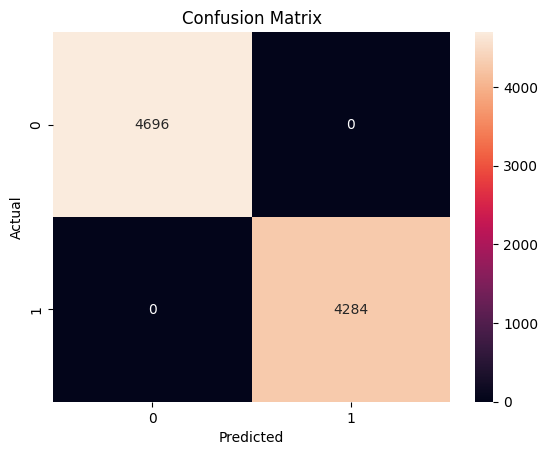

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
text = "Breaking news: Government announces new policy"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits)

print("Real News" if prediction==1 else "Fake News")

RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

In [18]:
text = "Breaking news: Government announces new policy"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

inputs = {key: value.to(model.device) for key, value in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits)

print("Real News" if prediction==1 else "Fake News")

Fake News


In [19]:
predictions = trainer.predict(val_dataset)

import numpy as np
preds = np.argmax(predictions.predictions, axis=1)

In [20]:
for i in range(len(preds)):
    if preds[i] != val_labels.iloc[i]:
        print("Text:", val_texts.iloc[i][:200])
        print("Actual:", val_labels.iloc[i])
        print("Predicted:", preds[i])
        print("---------------")

In [21]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,   # faster training
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Step,Training Loss
500,0.028831
1000,0.014429
1500,0.001845
2000,0.002424
2500,0.005120
3000,0.000015
3500,0.002615
4000,0.001953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4490, training_loss=0.006571515780543796, metrics={'train_runtime': 1334.1263, 'train_samples_per_second': 26.922, 'train_steps_per_second': 3.365, 'total_flos': 2378982012463104.0, 'train_loss': 0.006571515780543796, 'epoch': 1.0})

In [24]:
predictions = trainer.predict(val_dataset)

import numpy as np
preds = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

